# Jaguar Re-ID — RNN Baseline

**Architecture** : Reshape(224, 672) → LSTM(128) → Dense(128) → Dense(31)  
**Approche** : L'image est traitée comme une séquence de 224 lignes de pixels (672 features = 224×3 par ligne)  
**Note** : Les RNN (Recurrent Neural Networks) sont conçus pour des données **séquentielles** (texte, audio, séries temporelles). 
Appliqués à des images, ils perdent la structure spatiale 2D — chaque ligne est traitée indépendamment de ses voisines verticales. 
Ce notebook explore volontairement cette inadéquation pour comprendre les limites des RNN sur des tâches visuelles.

## 1. Setup & data loading

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# GPU setup — LD_LIBRARY_PATH must be set before TF loads CUDA
nvidia_libs = glob.glob(os.path.join(sys.prefix, 'lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Memory growth — avoid grabbing all VRAM at once (other processes may be running)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    print("WARNING: No GPU detected, training will be slow on CPU!")
    print("Run this in terminal first: export LD_LIBRARY_PATH=$(python3 -c \"import glob; print(':'.join(glob.glob('env/lib/python*/site-packages/nvidia/*/lib')))\")")
    print("Then restart the Jupyter kernel.")

I0000 00:00:1776158659.008180 1596207 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
MODEL_NAME   = 'rnn_baseline'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

I0000 00:00:1776158738.921285 1596207 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46758 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Reshape image (224, 224, 3) → sequence (224, 672)
        # Chaque ligne de pixels devient un timestep
        layers.Reshape((IMG_SIZE, IMG_SIZE * 3)),

        # LSTM traite les 224 lignes séquentiellement
        layers.LSTM(128),

        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "rnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 224, 672)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,623 (1.64 MB)

 Trainable params: 430,623 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (rnn_baseline) ===


I0000 00:00:1776158755.110564 1596609 cuda_dnn.cc:461] Loaded cuDNN version 92000


  lr_0.01: val_acc=0.0950 (best epoch=48)
  lr_0.001: val_acc=0.4142 (best epoch=100)
  lr_0.0001: val_acc=0.6095 (best epoch=77)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0001,0.609499,77
1,lr_0.001,0.414248,100
2,lr_0.01,0.094987,48



Best: lr_0.0001 → val_acc=0.6095


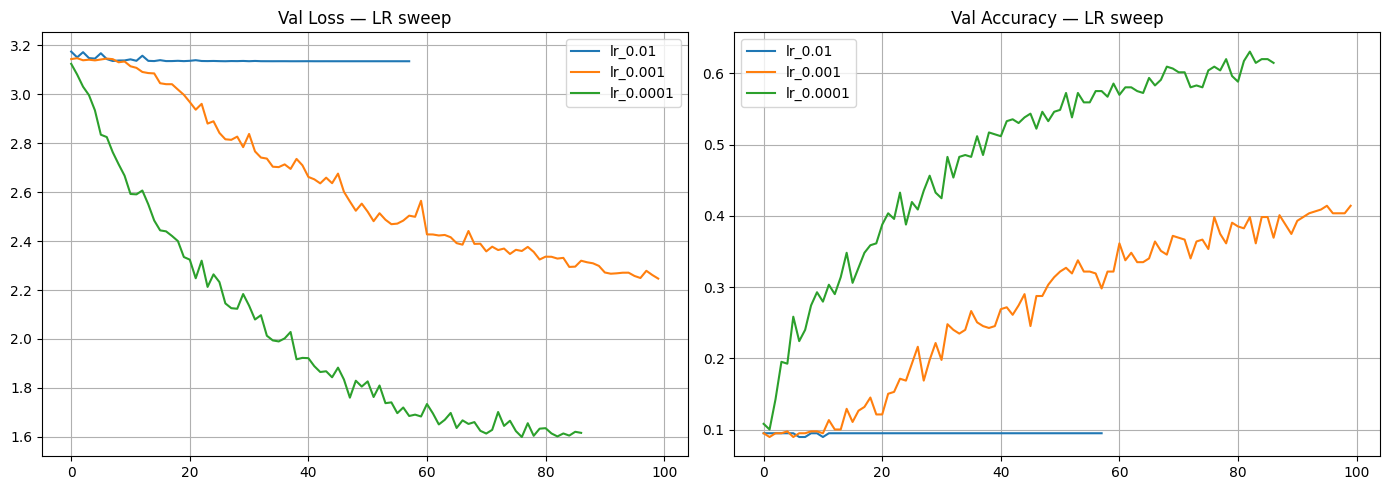

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.0811 - loss: 3.2967 - val_accuracy: 0.1055 - val_loss: 3.1971 - learning_rate: 1.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1009 - loss: 3.1637 - val_accuracy: 0.1346 - val_loss: 3.1345 - learning_rate: 1.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1299 - loss: 3.0949 - val_accuracy: 0.1240 - val_loss: 3.0735 - learning_rate: 1.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1669 - loss: 3.0381 - val_accuracy: 0.1425 - val_loss: 3.0521 - learning_rate: 1.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.1675 - loss: 2.9885 - val_accuracy: 0.1609 - val_loss: 2.9982 - learning_rate: 1.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.1913 - loss: 2.9443 - val_accuracy: 0.1689 - val_loss: 2.9625 - learning_rate: 1.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 

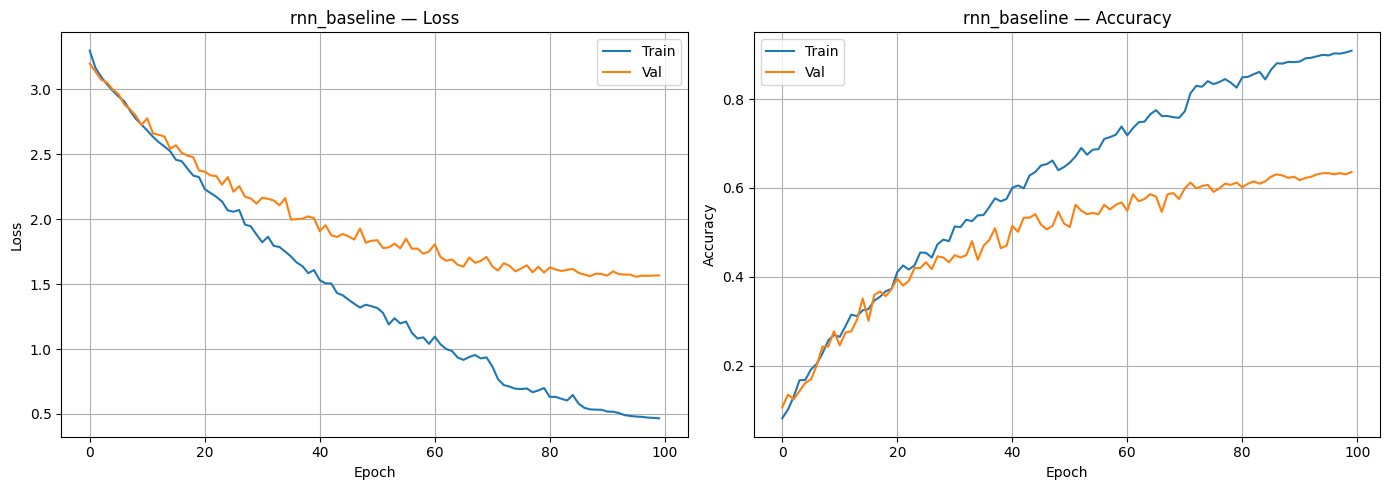

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

rnn_baseline (best LR=0.0001):
  Train — Loss: 0.4692, Acc: 0.9030
  Val   — Loss: 1.5566, Acc: 0.6332


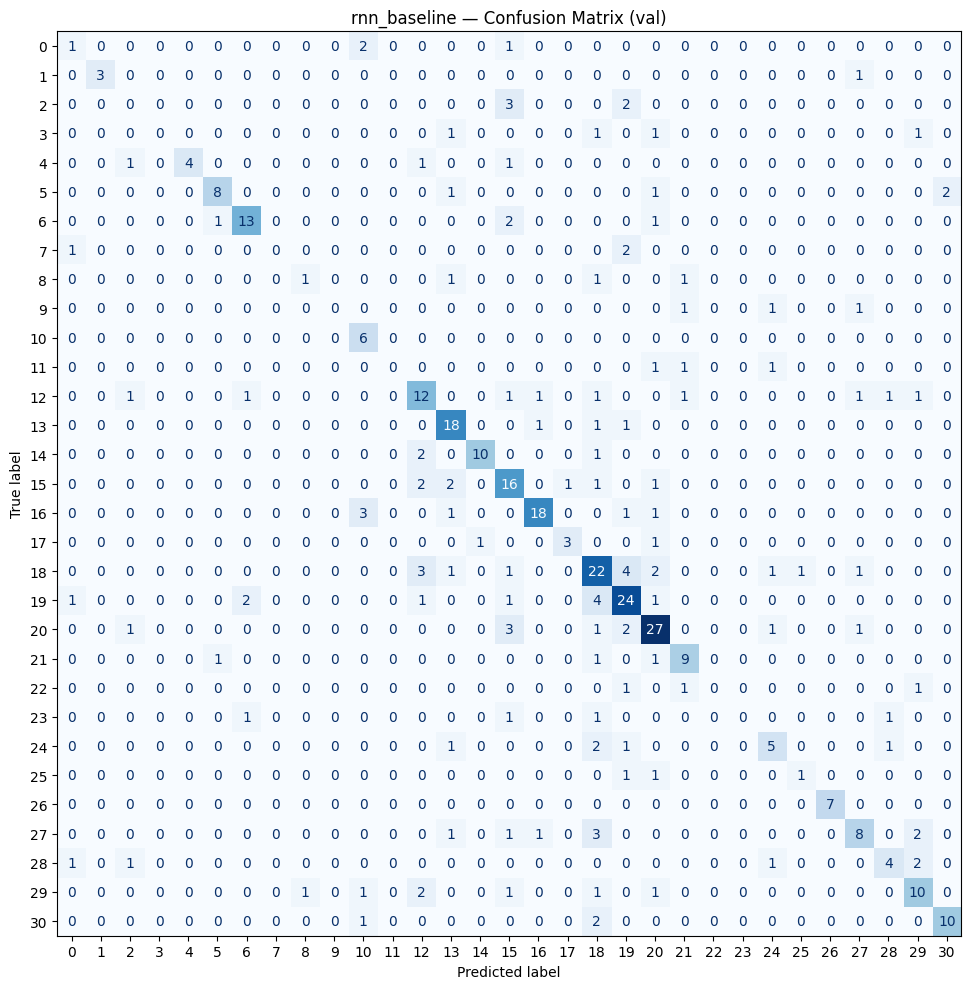

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 77 epochs
Epoch 1/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.0987 - loss: 3.2186
Epoch 2/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1140 - loss: 3.1095
Epoch 3/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1330 - loss: 3.0490
Epoch 4/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1726 - loss: 3.0025
Epoch 5/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1921 - loss: 2.9261
Epoch 6/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1789 - loss: 2.9176
Epoch 7/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2142 - loss: 2.8617
Epoch 8/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2264 - loss: 2.8149
Epoch 9/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2106 - loss: 2.8281
Epoch 10/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2575 - loss: 2.7444
Epoch 11/77
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2633 - loss: 2.7007
Epoch 12

In [14]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_rnn_baseline.csv


,row_id,similarity
0,0,0.942248
1,1,0.688603
2,2,0.619208
3,3,0.930007
4,4,0.796697


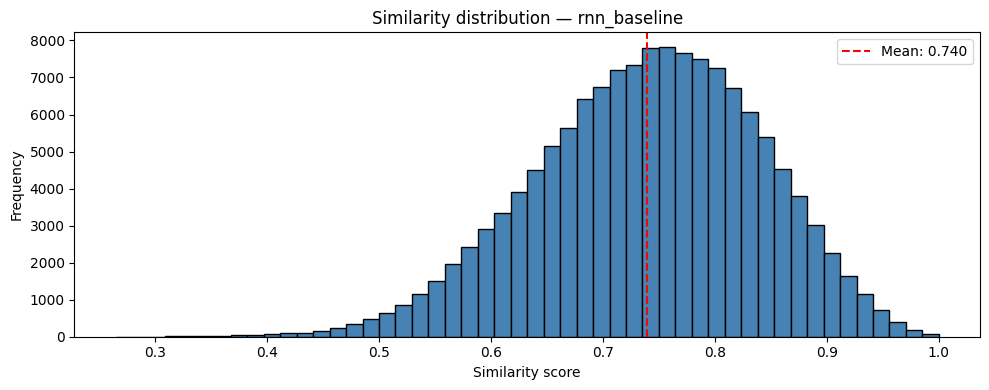

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.9030 | 0.6332 |
| Loss     | 0.4692 | 1.5566 |
| Overfitting ? | — | Oui, sévère : gap = 27.0 pts |
| Kaggle Score (public) | — | 0.179 |
| Kaggle Score (private) | — | 0.151 |

### Comparaison vs les autres baselines

| Modèle | Params | Val Acc | Gap overfit | Kaggle (pub/priv) |
|--------|--------|---------|-------------|-------------------|
| Linéaire | 4.6M | 73.1% | ~27 pts | 0.165 / — |
| MLP | 38.5M | 65.96% | ~33 pts | 0.164 / 0.178 |
| CNN baseline | 113K | 68.87% | ~9 pts | 0.267 / 0.264 |
| **RNN baseline** | **430K** | **63.32%** | **27.0 pts** | **0.179 / 0.151** |

Le RNN baseline est le **pire modèle en val_acc** (63.3%) et se situe au niveau du linéaire/MLP en Kaggle (~0.17), très loin du CNN baseline (0.267). C'est le résultat attendu : les RNN ne sont pas conçus pour les images.

### Pourquoi les RNN sont inadaptés aux images

Les RNN (Recurrent Neural Networks) ont été conçus pour traiter des **données séquentielles** : texte, audio, séries temporelles — des données où l'ordre des éléments porte un sens (un mot dépend des mots précédents, une note de musique dépend des notes passées).

Appliqué à une image, le LSTM traite les 224 lignes de pixels **de haut en bas**, comme s'il lisait un texte. Cela pose 3 problèmes fondamentaux :

1. **Perte de la structure spatiale 2D** : les rosettes du jaguar sont des motifs 2D qui s'étendent sur plusieurs lignes ET colonnes. Le LSTM peut corréler les lignes entre elles (verticalement), mais au sein d'une ligne, les 672 valeurs (224 pixels × 3 canaux) sont traitées comme un vecteur plat — il n'y a aucune notion de voisinage horizontal. Un CNN, avec ses filtres 3×3, capture naturellement les corrélations dans les deux dimensions.

2. **Séquence trop longue** : 224 timesteps est une séquence longue pour un LSTM. Malgré le mécanisme de gates (forget gate, input gate), l'information des premières lignes (haut de l'image) se dilue au fil de la propagation. Le LSTM tend à surpondérer les dernières lignes (bas de l'image), alors que les motifs discriminants d'un jaguar peuvent être n'importe où.

3. **Pas d'invariance par translation** : un CNN détecte un motif (ex: rosette) quelle que soit sa position dans l'image grâce au partage de poids des filtres. Le LSTM n'a pas cette propriété — un motif en haut et le même motif en bas de l'image produisent des activations complètement différentes car le hidden state a accumulé des informations différentes.

### Analyse des hyperparamètres

#### 1. Architecture — Reshape(224, 672) → LSTM(128) → Dense(128) → Dense(31)

430K paramètres, dont 410K dans le LSTM seul. La formule des paramètres LSTM est `4 × (input_size + hidden_size + 1) × hidden_size = 4 × (672 + 128 + 1) × 128 = 410,112`. Le facteur 4 vient des 4 gates (input, forget, cell, output). C'est un modèle de taille comparable au CNN baseline (113K) et CNN v4 (1.64M), mais les paramètres sont concentrés dans une seule couche récurrente au lieu d'être répartis sur plusieurs niveaux d'abstraction.

**Verdict** : L'architecture à une seule couche LSTM est la plus simple possible. Elle ne permet qu'un seul niveau d'abstraction temporelle, là où les CNN empilent des niveaux hiérarchiques (bords → textures → motifs → objets).

#### 2. Learning rate — sensibilité inversée vs CNN

| LR | RNN val_acc | CNN baseline val_acc | Diff |
|----|-----------|-----------|------|
| 0.01 | 0.0950 | 0.0950 | = (les deux s'effondrent) |
| 0.001 | 0.4142 | 0.7203 | −30.6 pts |
| 0.0001 | **0.6095** | 0.3034 | +30.6 pts |

Le LR optimal est **inversé** : 0.0001 pour le RNN vs 0.001 pour le CNN. Les RNN sont plus sensibles aux LR élevés à cause du **gradient flow à travers le temps** : à chaque timestep, les gradients sont multipliés par les poids récurrents. Avec 224 timesteps, un LR trop élevé amplifie les oscillations et cause de l'instabilité (exploding gradients). Le LSTM atténue ce problème grâce à ses gates, mais ne l'élimine pas — d'où le besoin d'un LR plus conservateur.

Le lr=0.001 donne seulement 41.4% — le LSTM n'arrive pas à se stabiliser. Le lr=0.0001 est le seul qui permet un apprentissage correct, mais la convergence est lente (best epoch 77, sur 100 epochs max).

#### 3. LR schedule — convergence très lente

3 réductions de LR : epoch 71 (→5e-5), 85 (→2.5e-5), 93 (→1.25e-5). EarlyStopping non déclenché — le modèle a utilisé les 100 epochs.

**Comparaison CNN baseline** : le CNN converge en ~55 epochs avec lr=0.001. Le RNN a besoin de 100 epochs avec un LR 10× plus petit. La convergence lente est symptomatique : le LSTM apprend difficilement des patterns utiles dans une séquence de lignes de pixels car le signal est faible et bruité.

#### 4. Overfitting — sévère, sans régularisation

Gap de 27.0 pts (train 90.3% vs val 63.3%). C'est au niveau du linéaire (~27 pts) et du MLP (~33 pts), et bien pire que le CNN baseline (~9 pts). Avec 430K paramètres et aucune régularisation (pas de Dropout, BatchNorm, L2, ni augmentation), le LSTM mémorise les séquences de lignes du train set sans généraliser.

#### 5. Kaggle score — embeddings non discriminants

0.179/0.151, à peine au-dessus du linéaire (0.165). Les embeddings LSTM de 128 dimensions ne capturent pas les motifs visuels discriminants des jaguars. Le LSTM encode une **mémoire de la lecture séquentielle** des lignes (« après telles lignes sombres, il y avait telles lignes claires »), mais pas la **structure spatiale** (« il y a une rosette de telle forme à tel endroit »). Pour la re-ID par cosine similarity, ces embeddings séquentiels sont quasi inutiles.

### Verdict

- [x] Improvable → Instructions pour v1
- [ ] Not Improvable → Plafond atteint
- [ ] Dead-end → On abandonne cette architecture

**Justification** : Malgré l'inadéquation structurelle des RNN pour les images, il reste de la marge d'amélioration technique : aucune régularisation, une seule couche LSTM, lecture unidirectionnelle. L'intérêt pédagogique est de mesurer combien ces améliorations peuvent compenser un biais inductif inadapté.

**Instructions pour v1** :
- **Bidirectional LSTM** : traiter l'image dans les deux sens (haut→bas ET bas→haut) pour que le modèle ne surpondère pas les dernières lignes. Le Bidirectional double le hidden state (256 dims) et devrait améliorer la couverture spatiale
- **Dropout(0.3)** après le LSTM : le gap de 27 pts montre que la régularisation est nécessaire. Le `recurrent_dropout` dans le LSTM régularise aussi les connexions temporelles
- **Augmentation moderate** : flip + brightness + contrast, comme validé sur les CNN
- **Garder lr=0.0001** : le seul LR qui fonctionne pour cette architecture

### Interprétation

_Ce notebook illustre parfaitement pourquoi le choix de l'architecture doit être guidé par la nature des données. Les RNN ont un **biais inductif séquentiel** : ils supposent que les données ont un ordre temporel où le passé influence le futur. Les images n'ont pas cette propriété — le pixel (0,0) n'est pas "avant" le pixel (100,100), ils coexistent spatialement. Les CNN ont le bon biais inductif pour les images : localité (un pixel est corrélé à ses voisins) et invariance par translation (un motif est le même partout). Le score Kaggle de 0.179 vs 0.267 (CNN baseline) quantifie le coût de cette inadéquation architecturale. Même avec des améliorations (Bidirectional, Dropout), le plafond des RNN sur des images sera structurellement inférieur aux CNN, car aucune quantité de régularisation ne peut compenser l'absence de biais spatial 2D._